In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Data Loading And Inspection

In [3]:
df = pd.read_csv("../data/application_train.csv")
print(f'Shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nData types: {df.dtypes}')

Shape: (307511, 122)

Column names: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEAR

In [20]:
print('=== First 5 rows ===')
print(df.head())
print('\n=== INFO ===')
print(df.info())
print('\n=== DESCRIBE ===')
print(df.describe().round(2))


=== First 5 rows ===
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...          

# 2. Missing data report


In [5]:
missing_report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2),
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

missing_report = missing_report[missing_report['missing_pct'] > 0]
print('Missing Data Report:')
print(missing_report)

Missing Data Report:
                          missing_count  missing_pct    dtype
COMMONAREA_MEDI                  214865        69.87  float64
COMMONAREA_AVG                   214865        69.87  float64
COMMONAREA_MODE                  214865        69.87  float64
NONLIVINGAPARTMENTS_MODE         213514        69.43  float64
NONLIVINGAPARTMENTS_AVG          213514        69.43  float64
...                                 ...          ...      ...
OBS_30_CNT_SOCIAL_CIRCLE           1021         0.33  float64
OBS_60_CNT_SOCIAL_CIRCLE           1021         0.33  float64
DEF_60_CNT_SOCIAL_CIRCLE           1021         0.33  float64
EXT_SOURCE_2                        660         0.21  float64
AMT_GOODS_PRICE                     278         0.09  float64

[64 rows x 3 columns]


# 3. 'Target'  Distribution and Class Imbalance

In [12]:
print(df['TARGET'].value_counts(normalize=True))

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [18]:
ratio = df['TARGET'].value_counts(normalize=True)[0]/df['TARGET'].value_counts(normalize=True)[1]
print(f'Class Imbalance ratio is: {ratio.round(2)}')

Class Imbalance ratio is: 11.39


# 4. Default Rate by Customer Segments

In [22]:
cols = [
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE"
]

for col in cols:
    print(f'=== deafult fate by {col} ===')
    default_rate = df.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    print(default_rate)

=== deafult fate by NAME_CONTRACT_TYPE ===
NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64
=== deafult fate by NAME_INCOME_TYPE ===
NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64
=== deafult fate by OCCUPATION_TYPE ===
OCCUPATION_TYPE
Low-skill Laborers       0.171524
Drivers                  0.113261
Waiters/barmen staff     0.112760
Security staff           0.107424
Laborers                 0.105788
Cooking staff            0.104440
Sales staff              0.096318
Cleaning staff           0.096067
Realty agents            0.078562
Secretaries              0.070498
Medicine staff           0.067002
Private service staff    0.065988
IT staff                 0.064639
HR s

# 5.Distribution Plots

**Most financial features are right-skewed and contain some outliers. Age is more evenly distributed than the other features.**

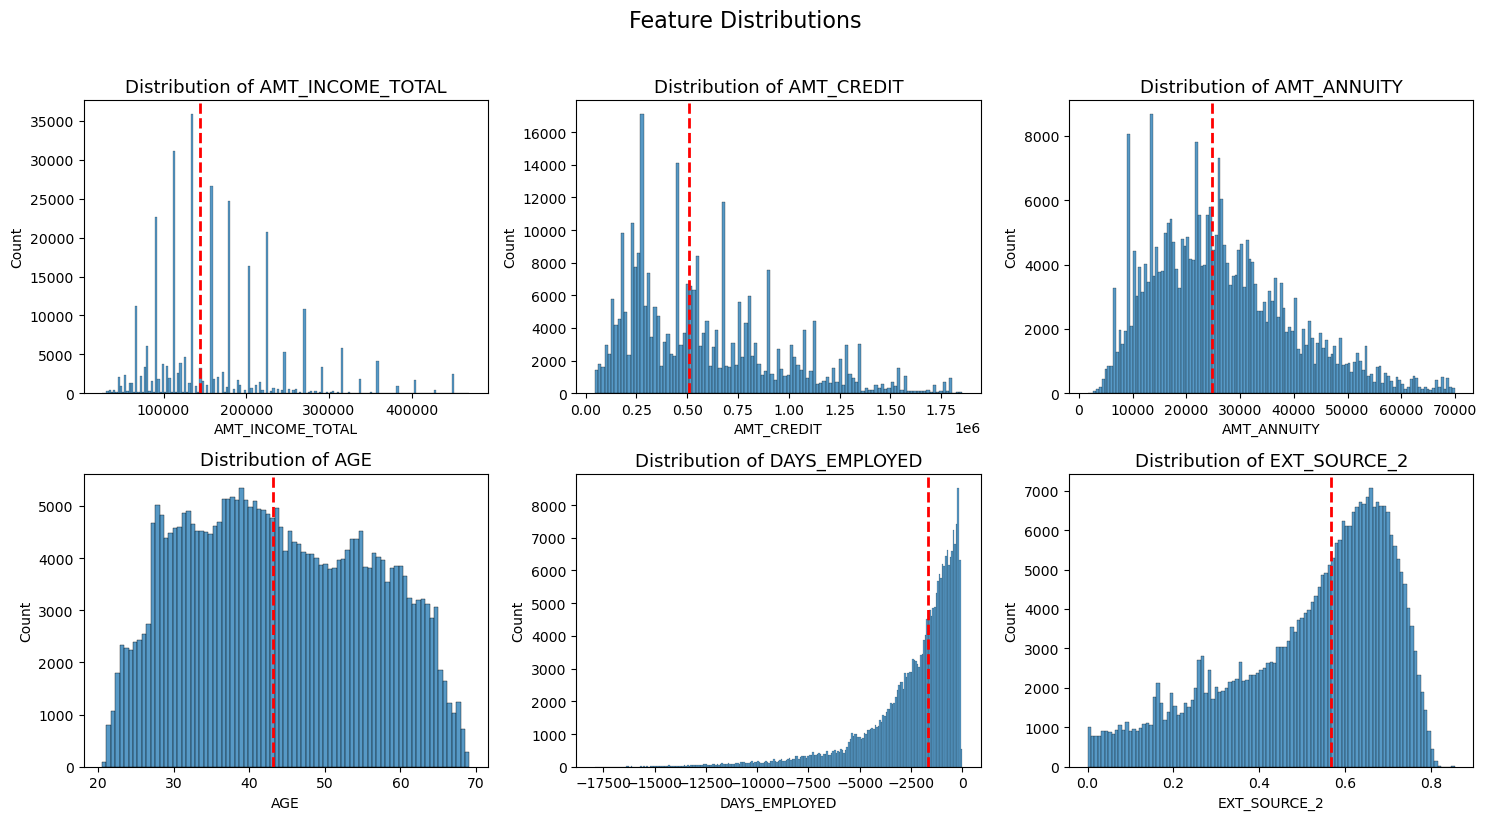

In [30]:
df['AGE'] = -df["DAYS_BIRTH"] / 365

features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_2"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flatten(), features):
    data = df[feature].dropna()

    if feature in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]:
        data = data[data < data.quantile(0.99)]

    if feature == "DAYS_EMPLOYED":
        data = data[data != 365243]

    sns.histplot(data, ax=ax)
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=2)
    ax.set_title(f"Distribution of {feature}", fontsize=13)

plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 6. Correlation Analysis of Features Most Related to TARGET

**XT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 have the strongest relationship with TARGET. Some features are highly correlated with each other and may contain similar information.**

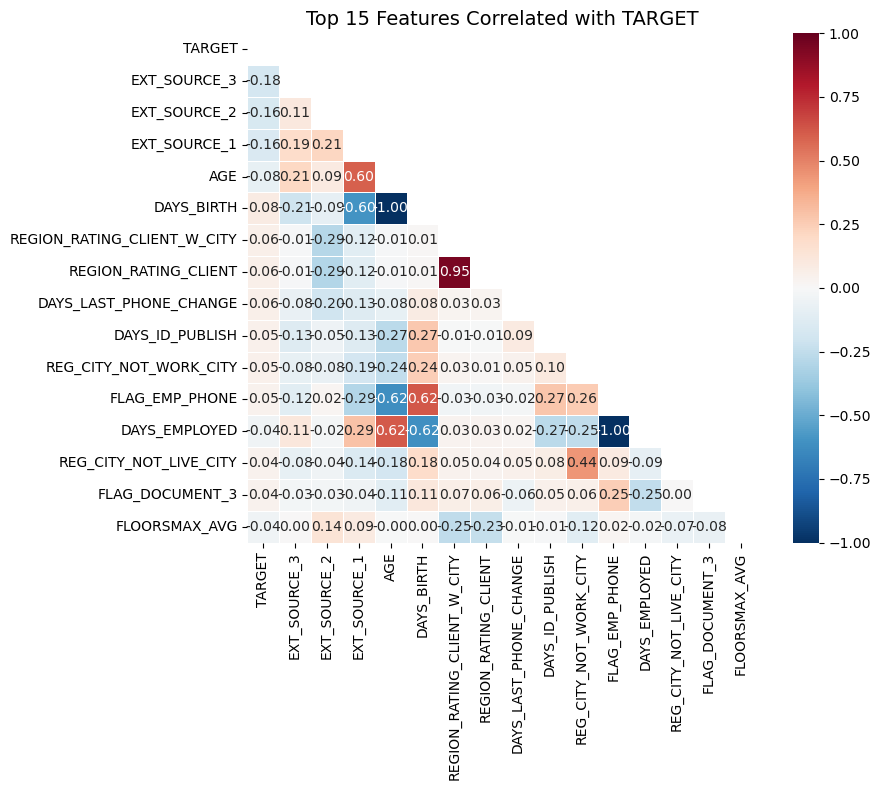

High correlation pairs (|r| > 0.7): [('AGE', 'DAYS_BIRTH', -0.9999999999999887), ('REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT', 0.9508422141646484), ('FLAG_EMP_PHONE', 'DAYS_EMPLOYED', -0.9997550114443878)]


In [37]:
numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corr()['TARGET'].abs().sort_values(ascending=False)
top_15_features = target_corr.index[:16]

corr = numeric_df[top_15_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)

plt.title('Top 15 Features Correlated with TARGET', fontsize=14)
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
print('High correlation pairs (|r| > 0.7):', high_corr if high_corr else 'None found')

# 7. Bureau Records per Application and Default Rate

**Default rates change across different numbers of bureau records. The number of bureau records may help predict whether an applicant will default.**

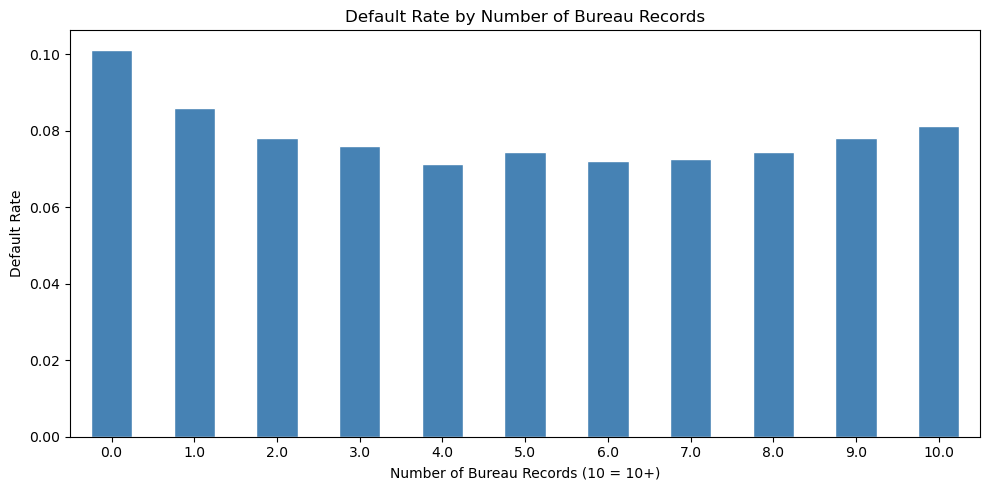

In [41]:
bureau = pd.read_csv("../data/bureau.csv")

bureau_count = (
    bureau.groupby("SK_ID_CURR")
          .size()
          .reset_index(name="num_bureau_records")
)

df = df.merge(bureau_count, on="SK_ID_CURR", how="left")
df["num_bureau_records"] = df["num_bureau_records"].fillna(0)

df["bureau_records_group"] = df["num_bureau_records"].clip(upper=10)

bureau_rates = (
    df.groupby("bureau_records_group")["TARGET"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 5))

bureau_rates.plot(kind="bar", color="steelblue", edgecolor="white")

plt.title("Default Rate by Number of Bureau Records")
plt.xlabel("Number of Bureau Records (10 = 10+)")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()